# Research attention concentrates on a subset of taxa

In [30]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

for candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    if (candidate / "data_helpers").is_dir() and (candidate / "checklists").is_dir():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError("Could not locate the biodiversity repository root.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from data_helpers import results_config, visualization
from data_helpers.prep import taxa_analysis_prep
from data_helpers.analysis.taxa import skew as taxa_skew
from data_helpers.analysis.taxa import skew_plotting as taxa_skew_plotting
from data_helpers.analysis.taxa import geography as taxa_geography

In [31]:
visualization.apply_style()

RESULTS_CONFIG = results_config.load_results_config()
# One analysis key. Everything else read here is shared infrastructure: the two
# data-processing handoffs (taxa_analysis_prep, and the corpus for study countries).
CONFIG = RESULTS_CONFIG["taxonomic_lens"]
PREP_CONFIG = RESULTS_CONFIG["taxa_analysis_prep"]

MAPPING = taxa_analysis_prep.load_taxa_mapping(PROJECT_ROOT / PREP_CONFIG["taxa_group_mapping"])
BROAD_SCHEME = MAPPING["schemes"]["broad"]

BENCHMARK_GROUPS = tuple(CONFIG["benchmark_groups"])
BROAD_COLORS = {group: BROAD_SCHEME["group_colors"][group] for group in BENCHMARK_GROUPS}

PREPARED = taxa_analysis_prep.TaxaPreparedStore(PROJECT_ROOT / PREP_CONFIG["output_directory"])
RESULTS = taxa_skew.TaxaSkewResultStore(
    PROJECT_ROOT / CONFIG["output_directory"],
    table_subdirectory=CONFIG["table_subdirectory"],
    figure_subdirectory=CONFIG["figure_subdirectory"],
)
ARTIFACT_PREFIX = CONFIG["artifact_prefix"]


# Every exported file carries this result's prefix.
def artifact(name: str) -> str:
    return f"{ARTIFACT_PREFIX}_{name}"


print(f"Benchmark groups: {', '.join(BENCHMARK_GROUPS)}")
print(f"Stack order (bottom to top): {', '.join(CONFIG['benchmark_group_stack_order'])}")
print(f"Outputs: {CONFIG['output_directory']}")

Benchmark groups: Vertebrates, Invertebrates, Plants, Fungi, Other
Stack order (bottom to top): Invertebrates, Fungi, Other, Plants, Vertebrates
Outputs: notebooks/results/outputs/04_taxonomic_lens


## 1. One load, two denominators

The handoff is loaded once, over negative-direction evidence from complete years
2000-2025. **Universe** is every in-scope publication; **anchor** is the subset
resolving to at least one benchmarkable broad group — the scope every share below is
computed over. The gap between the two is reported in the `denominators` table below
and restated as an interpretation boundary in Section 3.

In [32]:
bundle = PREPARED.load(mapping=MAPPING)
print(f"Handoff: {len(bundle.articles):,} rows / {bundle.articles['UT'].nunique():,} unique UTs.")
print(f"Grouping rules SHA-256: {bundle.manifest['grouping_rules_sha256'][:16]}…")

anchor = taxa_skew.prepare_taxa_skew_from_prepared(
    bundle.articles,
    benchmark_groups=BENCHMARK_GROUPS,
    unresolved_group=CONFIG["unresolved_group"],
    match_status_audit=bundle.audit_frame("match_status"),
    group_reason_audit=bundle.audit_frame("broad_group_reason"),
    special_value_audit=bundle.audit_frame("special_value"),
    auxiliary_label_audit=bundle.audit_frame("auxiliary_labels"),
    direction=CONFIG["direction"],
    start_year=CONFIG["primary_start_year"],
    end_year=CONFIG["primary_end_year"],
)

# The universe is every in-scope publication; the anchor is those that resolve to a
# benchmarkable broad group. The gap between them is the resolution caveat, reported in 2b.
UNIVERSE = bundle.articles[
    bundle.articles["s2_dir"].eq(CONFIG["direction"])
    & bundle.articles["publication_year"].between(
        CONFIG["primary_start_year"], CONFIG["primary_end_year"]
    )
]
N_UNIVERSE = int(UNIVERSE["UT"].nunique())
N_ANCHOR = int(anchor.included["UT"].nunique())

Handoff: 605,199 rows / 605,199 unique UTs.
Grouping rules SHA-256: c211129eb583ecf5…


In [33]:
denominators = pd.DataFrame(
    [
        {
            "scope": "Universe (negative, 2000–2025)",
            "requirement": "in scope",
            "n_publications": N_UNIVERSE,
            "share_of_universe_pct": 100.0,
        },
        {
            "scope": "Anchor (the finding)",
            "requirement": "≥1 benchmarkable broad group",
            "n_publications": N_ANCHOR,
            "share_of_universe_pct": N_ANCHOR / N_UNIVERSE * 100,
        },
    ]
)
RESULTS.save_table(denominators, artifact("denominators"))
display(
    denominators.style.format(
        {"n_publications": "{:,}", "share_of_universe_pct": "{:.2f}%"}
    ).hide(axis="index")
)
print(
    f"{N_UNIVERSE - N_ANCHOR:,} in-scope publications name no benchmarkable group and are "
    "excluded from every number below."
)

Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/04_taxonomic_lens/csv/04_denominators.csv


scope,requirement,n_publications,share_of_universe_pct
"Universe (negative, 2000–2025)",in scope,"245,168",100.00%
Anchor (the finding),≥1 benchmarkable broad group,"171,791",70.07%


73,377 in-scope publications name no benchmarkable group and are excluded from every number below.


## 2. Attention versus described diversity

The comparison the finding rests on: each broad group's share of publication attention against
its share of described species. Attention is article-balanced — a publication naming two groups
contributes half a publication to each, never one to both.

In [34]:
benchmark = bundle.benchmark
anchor_analysis = taxa_skew.analyze_taxonomic_skew(
    anchor,
    benchmark,
    benchmark_groups=BENCHMARK_GROUPS,
    n_bootstrap=CONFIG["bootstrap_replicates"],
    seed=CONFIG["random_seed"],
)
RESULTS.save_table(anchor_analysis.comparison, artifact("attention_vs_described_diversity"))

display(
    anchor_analysis.comparison[
        [
            "broad_group",
            "n_unique_publications",
            "fractional_attention_share_pct",
            "attention_ci_low_pct",
            "attention_ci_high_pct",
            "described_species_count",
            "described_species_share_pct",
            "attention_minus_described_pp",
            "representation_ratio",
            "representation",
        ]
    ]
    .style.format(
        {
            "n_unique_publications": "{:,}",
            "fractional_attention_share_pct": "{:.2f}%",
            "attention_ci_low_pct": "{:.2f}%",
            "attention_ci_high_pct": "{:.2f}%",
            "described_species_count": "{:,}",
            "described_species_share_pct": "{:.2f}%",
            "attention_minus_described_pp": "{:+.2f} pp",
            "representation_ratio": "{:.2f}×",
        }
    )
    .hide(axis="index")
)

ANCHOR = anchor_analysis.comparison.set_index("broad_group")
for group in ("Vertebrates", "Invertebrates"):
    row = ANCHOR.loc[group]
    print(
        f"{group}: {row['fractional_attention_share_pct']:.1f}% of attention versus "
        f"{row['described_species_share_pct']:.1f}% of described species "
        f"({row['representation_ratio']:.2f}×, {row['attention_minus_described_pp']:+.1f} pp)."
    )

Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/04_taxonomic_lens/csv/04_attention_vs_described_diversity.csv


broad_group,n_unique_publications,fractional_attention_share_pct,attention_ci_low_pct,attention_ci_high_pct,described_species_count,described_species_share_pct,attention_minus_described_pp,representation_ratio,representation
Vertebrates,"64,161",34.83%,34.59%,35.05%,"120,268",4.61%,+30.21 pp,7.55×,Over-attended
Invertebrates,"39,952",19.71%,19.53%,19.90%,"1,694,587",65.00%,-45.29 pp,0.30×,Under-attended
Plants,"65,412",33.99%,33.77%,34.21%,"446,842",17.14%,+16.86 pp,1.98×,Over-attended
Fungi,"7,518",2.94%,2.87%,3.01%,"172,327",6.61%,-3.67 pp,0.44×,Under-attended
Other,"18,673",8.54%,8.41%,8.65%,"173,190",6.64%,+1.89 pp,1.28×,Over-attended


Vertebrates: 34.8% of attention versus 4.6% of described species (7.55×, +30.2 pp).
Invertebrates: 19.7% of attention versus 65.0% of described species (0.30×, -45.3 pp).


### 2a. The geographic comparison — legacy WDI benchmark (superseded 2026-08-16)

**Superseded, kept for comparison only.** This subsection's benchmark (World Bank WDI
threatened bird+mammal counts, summed per country then per region) and its pooled
evidence count (publication–country occurrences, also summed per region — a
double-count this subsection's own code comment names below) are retained here
unchanged. They are no longer the source of the manuscript's Figure 4c/4d numbers.
**2a-revised**, immediately below, replaces both: the benchmark with a Starnes et al.
(2026) IPBES-native source, and the evidence count with a proper article-per-region
deduplication. Full rationale in the 2026-08-16 decisions-log entry.

The benchmark changes but the question does not. Section 2 asks whether attention tracks
**described diversity**; this asks whether, within one group, evidence tracks **documented
threat**. The two benchmarks are unrelated — GBIF accepted species and IUCN threatened
birds + mammals — which is what makes the pair worth reporting together.

Counting matches `summarise_gap_by_region` throughout: unique documents per country, summed
within region, so a yearly share and the pooled share are the same statistic at different
resolutions.

In [35]:
import numpy as np

from data_helpers.analysis.geo.geography import load_crosswalk
from data_helpers.analysis.taxa import threat_gap as taxa_threat_gap
from data_helpers.analysis.taxa import threat_gap_plotting as taxa_gap_plotting

GAP_GROUP = CONFIG["threat_gap_group"]
GAP_SLUG = taxa_geography.group_slug(GAP_GROUP)
CROSSWALK = load_crosswalk()

publication_countries = taxa_geography.load_publication_countries(
    PROJECT_ROOT / CONFIG["geography_source"]
)
taxa_lq, taxa_geo_audit, taxa_geo_coverage = taxa_geography.taxa_country_specialization(
    anchor.included,
    publication_countries,
    benchmark_groups=BENCHMARK_GROUPS,
    min_support=CONFIG["geography_min_support"],
    eb_kappa=CONFIG["geography_eb_kappa"],
)

# Coverage of the geographic comparison -- the share of the anchor carrying a mapped
# study country. Reported as an interpretation boundary, so it is exported, not only printed.
RESULTS.save_table(taxa_geo_coverage, artifact("taxa_geography_coverage"))
# Reported later as an interpretation boundary (Section 3), computed here
# alongside taxa_geo_coverage so it cannot drift from the frame it summarises.
GEO_COVERAGE_PCT = float(taxa_geo_coverage.loc[1, "share_of_scope_pct"])

# (1) Evidence side. Every country the LQ was computed for, cutoff flagged not applied.
gap_evidence = taxa_threat_gap.evidence_by_country(taxa_lq, CROSSWALK, group=GAP_GROUP)
RESULTS.save_table(
    taxa_threat_gap.select_export_columns(gap_evidence, "evidence-by-country"),
    artifact(f"{GAP_SLUG}_evidence_by_country"),
)
print(
    f"(1) Evidence: {len(gap_evidence):,} countries, "
    f"{gap_evidence['n_group_publications'].sum():,} {GAP_GROUP.lower()} publications; "
    f"{int(gap_evidence['meets_min_support'].sum())} clear the "
    f"{CONFIG['geography_min_support']}-publication line, "
    f"{int((~gap_evidence['meets_min_support']).sum())} fall below it and are kept anyway."
)
display(
    gap_evidence.head(15)
    .style.format(
        {
            "n_group_publications": "{:,}",
            "n_country_publications": "{:,}",
            "share_of_group_evidence_pct": "{:.2f}%",
            "within_country_share_pct": "{:.1f}%",
            "corpus_share_pct": "{:.1f}%",
            "lq": "{:.2f}×",
            "log2_lq": "{:+.2f}",
            "lq_eb": "{:.2f}×",
            "log2_lq_eb": "{:+.2f}",
        }
    )
    .hide(axis="index")
)

# (2) Threat side, independent of the corpus entirely.
gap_threat = taxa_threat_gap.threatened_species_by_country(
    PROJECT_ROOT / CONFIG["threat_gap_source"]
)
RESULTS.save_table(
    taxa_threat_gap.select_export_columns(gap_threat, "threatened-species-by-country"),
    artifact("threatened_species_by_country"),
)
# These are constant down every row, so they are facts about the table rather than
# columns in it -- stated here and in the manifest instead of repeated 215 times.
print(
    f"\n(2) Threat: {len(gap_threat):,} countries, WDI year "
    f"{int(gap_threat['wdi_year'].max())}; "
    f"{int((~gap_threat['threat_counts_complete']).sum())} with an incomplete class set. "
    f"Fish are {gap_threat['threatened_fish'].sum() / gap_threat['threatened_vertebrates'].sum() * 100:.0f}% "
    "of the birds+mammals+fish total, which is why the land subset is held apart."
)
display(
    gap_threat.head(15)
    .style.format(
        {
            column: "{:,.0f}"
            for column in (
                *taxa_threat_gap.THREAT_INDICATORS.values(),
                "threatened_vertebrates",
                "threatened_vertebrates_land",
                "threatened_total",
            )
        }
        | {"vertebrate_share_of_threatened_pct": "{:.1f}%", "wdi_year": "{:.0f}"}
    )
    .hide(axis="index")
)


# (3) The match. Inner: the exported table carries only countries with BOTH sides,
# which are the rows a ratio is defined on. This changes no value -- shares and ratios
# were always computed over matched countries -- it only decides which rows are kept.
# What is excluded is reported below rather than dropped silently.
gap_matched = taxa_threat_gap.match_evidence_and_threat(gap_evidence, gap_threat)
RESULTS.save_table(
    taxa_threat_gap.select_export_columns(gap_matched, "evidence-vs-threatened"),
    artifact(f"{GAP_SLUG}_evidence_vs_threatened"),
)
BOTH = gap_matched
EXCLUDED = gap_matched.attrs
print(f"\n(3) Match -- exported table is countries on BOTH sides only:")
print(f"    matched         : {EXCLUDED['n_matched_countries']:>4} countries (exported)")
print(
    f"    evidence only   : {EXCLUDED['n_evidence_only_countries']:>4} countries, "
    f"{EXCLUDED['evidence_only_publications']:,.0f} publications (excluded)"
)
print(
    f"    threat only     : {EXCLUDED['n_threat_only_countries']:>4} countries, "
    f"{EXCLUDED['threat_only_threatened_vertebrates_land']:,.0f} threatened land "
    "vertebrates (excluded)"
)
print(
    f"    retained: {BOTH['n_group_publications'].sum():,.0f} of "
    f"{gap_evidence['n_group_publications'].sum():,.0f} {GAP_GROUP.lower()} publications "
    f"({BOTH['n_group_publications'].sum() / gap_evidence['n_group_publications'].sum() * 100:.1f}%) "
    f"and {BOTH['threatened_vertebrates_land'].sum():,.0f} of "
    f"{gap_threat['threatened_vertebrates_land'].sum():,.0f} threatened land vertebrates "
    f"({BOTH['threatened_vertebrates_land'].sum() / gap_threat['threatened_vertebrates_land'].sum() * 100:.1f}%)."
)
# Named, because the largest exclusion is a policy artefact rather than a data gap:
# the World Bank has no economy for Taiwan, so it cannot appear on the threat side.
print(f"    evidence-only countries: {', '.join(EXCLUDED['evidence_only_countries'])}")
print(f"    threat-only countries  : {', '.join(EXCLUDED['threat_only_countries'])}")

# The geographic row of the manuscript figure. The regional table is the defensible
# unit -- country cells rest on counts too small to carry a ratio -- and the trend
# answers on the geographic axis the question panel B answers on the taxonomic one.
gap_regions = taxa_threat_gap.summarise_gap_by_region(gap_matched)
gap_regional_trend = taxa_threat_gap.regional_evidence_trend(
    anchor.included, publication_countries, gap_regions, CROSSWALK, group=GAP_GROUP
)
gap_regional_summary = taxa_threat_gap.summarise_regional_trend(gap_regional_trend)
RESULTS.save_table(gap_regions, artifact(f"{GAP_SLUG}_evidence_vs_threatened_by_region"))
RESULTS.save_table(
    gap_regional_trend, artifact(f"{GAP_SLUG}_regional_evidence_trend")
)
RESULTS.save_table(
    gap_regional_summary, artifact(f"{GAP_SLUG}_regional_evidence_trend_summary")
)
display(
    gap_regional_summary.style.format(
        {
            "start_share_pct": "{:.2f}%",
            "end_share_pct": "{:.2f}%",
            "change_pp": "{:+.2f} pp",
            "slope_pp_per_decade": "{:+.2f}",
            "threat_share_pct": "{:.2f}%",
            "start_ratio": "{:.2f}×",
            "end_ratio": "{:.2f}×",
        }
    ).hide(axis="index")
)
for row in gap_regional_summary.itertuples():
    print(
        f"{row.region}: {row.start_share_pct:.1f}% -> {row.end_share_pct:.1f}% of "
        f"{GAP_GROUP.lower()} evidence ({row.slope_pp_per_decade:+.2f} pp/decade); "
        f"representation {row.start_ratio:.2f}x -> {row.end_ratio:.2f}x."
    )


Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/04_taxonomic_lens/csv/04_taxa_geography_coverage.csv
Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/04_taxonomic_lens/csv/04_vertebrates_evidence_by_country.csv
(1) Evidence: 236 countries, 43,808 vertebrates publications; 104 clear the 100-publication line, 132 fall below it and are kept anyway.


iso3,country,region,subregion,broad_group,n_group_publications,n_country_publications,share_of_group_evidence_pct,within_country_share_pct,corpus_share_pct,lq,log2_lq,lq_eb,log2_lq_eb,meets_min_support
USA,United States of America (the),Americas,North America,Vertebrates,"8,751","19,006",19.98%,46.0%,39.7%,1.16×,+0.22,1.16×,+0.21,True
CAN,Canada,Americas,North America,Vertebrates,"2,802","5,090",6.40%,55.0%,39.7%,1.39×,+0.47,1.39×,+0.47,True
CHN,China,Asia and the Pacific,North-East Asia,Vertebrates,"2,659","9,727",6.07%,27.3%,39.7%,0.69×,-0.54,0.69×,-0.54,True
AUS,Australia,Asia and the Pacific,Oceania,Vertebrates,"2,308","5,040",5.27%,45.8%,39.7%,1.15×,+0.21,1.15×,+0.21,True
BRA,Brazil,Americas,South America,Vertebrates,"2,262","5,662",5.16%,40.0%,39.7%,1.01×,+0.01,1.01×,+0.01,True
ESP,Spain,Europe and Central Asia,Central and Western Europe,Vertebrates,"1,262","3,319",2.88%,38.0%,39.7%,0.96×,-0.06,0.96×,-0.06,True
IND,India,Asia and the Pacific,South Asia,Vertebrates,"1,168","3,662",2.67%,31.9%,39.7%,0.80×,-0.31,0.81×,-0.31,True
MEX,Mexico,Americas,Mesoamerica,Vertebrates,"1,075","2,435",2.45%,44.1%,39.7%,1.11×,+0.15,1.11×,+0.15,True
GBR,United Kingdom of Great Britain and Northern Ireland (the),Europe and Central Asia,Central and Western Europe,Vertebrates,945,"2,052",2.16%,46.1%,39.7%,1.16×,+0.22,1.16×,+0.21,True
ITA,Italy,Europe and Central Asia,Central and Western Europe,Vertebrates,870,"2,688",1.99%,32.4%,39.7%,0.82×,-0.29,0.82×,-0.29,True


Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/04_taxonomic_lens/csv/04_threatened_species_by_country.csv

(2) Threat: 215 countries, WDI year 2022; 0 with an incomplete class set. Fish are 61% of the birds+mammals+fish total, which is why the land subset is held apart.


iso3,country,region,subregion,wdi_year,threatened_birds,threatened_mammals,threatened_fish,threatened_higher_plants,threatened_vertebrates,threatened_vertebrates_land,threatened_total,vertebrate_share_of_threatened_pct,threat_counts_complete
MDG,Madagascar,Africa,East Africa and adjacent islands,2022,37,133,127,"2,894",297,170,"3,191",9.3%,True
ECU,Ecuador,Americas,South America,2022,86,49,99,"2,029",234,135,"2,263",10.3%,True
BRA,Brazil,Americas,South America,2022,155,97,360,"1,346",612,252,"1,958",31.3%,True
MEX,Mexico,Americas,Mesoamerica,2022,68,97,308,"1,426",473,165,"1,899",24.9%,True
IDN,Indonesia,Asia and the Pacific,South-East Asia,2022,161,212,366,977,739,373,"1,716",43.1%,True
MYS,Malaysia,Asia and the Pacific,South-East Asia,2022,67,80,183,"1,317",330,147,"1,647",20.0%,True
TZA,"Tanzania, the United Republic of",Africa,East Africa and adjacent islands,2022,46,45,219,"1,010",310,91,"1,320",23.5%,True
COL,Colombia,Americas,South America,2022,102,63,183,918,348,165,"1,266",27.5%,True
PHL,Philippines (the),Asia and the Pacific,South-East Asia,2022,91,42,143,903,276,133,"1,179",23.4%,True
CMR,Cameroon,Africa,Central Africa,2022,31,48,148,888,227,79,"1,115",20.4%,True


Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/04_taxonomic_lens/csv/04_vertebrates_evidence_vs_threatened.csv

(3) Match -- exported table is countries on BOTH sides only:
    matched         :  213 countries (exported)
    evidence only   :   23 countries, 332 publications (excluded)
    threat only     :    2 countries, 5 threatened land vertebrates (excluded)
    retained: 43,476 of 43,808 vertebrates publications (99.2%) and 8,388 of 8,393 threatened land vertebrates (99.9%).
    evidence-only countries: AIA, BES, BLM, BVT, CCK, COK, CXR, ESH, FLK, GLP, GUF, IOT, MSR, MTQ, MYT, NIU, PCN, REU, SGS, SHN, TKL, TWN, WLF
    threat-only countries  : MAF, SMR
Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/04_taxonomic_lens/csv/04_vertebrates_evidence_vs_threatened_by_region.csv
Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/04_taxonomic_lens/csv/04_vertebrates_regional_evidence_trend.csv
Saved: 

region,start_year,end_year,start_share_pct,end_share_pct,change_pp,slope_pp_per_decade,threat_share_pct,start_ratio,end_ratio
Africa,2000,2025,6.90%,9.70%,+2.80 pp,+1.21,27.61%,0.25×,0.35×
Asia and the Pacific,2000,2025,17.24%,35.31%,+18.07 pp,+6.06,36.71%,0.47×,0.96×
Europe and Central Asia,2000,2025,25.48%,20.28%,-5.19 pp,-2.99,13.70%,1.86×,1.48×
Americas,2000,2025,50.38%,34.71%,-15.68 pp,-4.28,21.98%,2.29×,1.58×


Africa: 6.9% -> 9.7% of vertebrates evidence (+1.21 pp/decade); representation 0.25x -> 0.35x.
Asia and the Pacific: 17.2% -> 35.3% of vertebrates evidence (+6.06 pp/decade); representation 0.47x -> 0.96x.
Europe and Central Asia: 25.5% -> 20.3% of vertebrates evidence (-2.99 pp/decade); representation 1.86x -> 1.48x.
Americas: 50.4% -> 34.7% of vertebrates evidence (-4.28 pp/decade); representation 2.29x -> 1.58x.


### 2a-revised. Starnes regional threat benchmark (2026-08-16)

Replaces the WDI benchmark above for Figure 4c/d. Two independent fixes, both required:

1. **Benchmark source.** Starnes, T. et al. (2026), *A new analysis of biodiversity and
   conservation knowledge products to support environmental assessments*
   (Zenodo doi:10.5281/zenodo.18348560) — an IUCN Red List disaggregation built on the
   same canonical IPBES regions/subregions dataset this repo's own `ipbes_regions.json`
   crosswalk traces to (subregion names match exactly; verified, not assumed, by
   `starnes_regional_threat_benchmark`, which raises on any that don't). Threatened =
   CR + EN + VU, computed directly from the category columns.

   **This is an all-taxa count**, not birds+mammals: no table in the 21-table Starnes
   release breaks threatened-species counts out by taxonomic group, and no
   species-level data is published that a bird/mammal cut could be rebuilt from. Per
   the 2026-08-16 decision, the evidence side therefore stays scoped to the broad
   `Vertebrates` group (unchanged from 2a above) rather than being narrowed to
   birds+mammals — narrowing only the evidence side would pair it against a benchmark
   that is *broader* than vertebrates (Starnes' "comprehensively assessed" set also
   includes cycads, corals, trees, conifers, selected crustaceans and insects, and
   cephalopods), which is a worse mismatch than the one being fixed. Neither side
   claims a taxonomic match the other can't back; both are "dominated by, but broader
   than," the comparison population. See the `threat_gap_starnes` module docstring.

   **Unresolved limitation, stated not hidden.** Starnes' Data Table 1a reports IPBES
   *subregion* rows only, with no region-level rollup and no statement that subregion
   counts are additive across a region. This sums them anyway — Starnes provides no
   region-level table or species-level data that would avoid or verify the sum — so a
   species ranging across more than one subregion of a region is very likely counted
   more than once in that region's total, exactly the non-additivity the WDI benchmark
   above already documents for itself. That limitation is a property of the source, not
   introduced here, and travels with every number below.

2. **Evidence-side dedup.** `pooled_regional_evidence` deduplicates directly to
   (article, region): an article studying two countries in the same region now
   contributes one region-occurrence, not two. A minority of articles genuinely span
   two regions and are counted once in each — the same convention the manuscript's
   counting rule already states, now actually enforced at the region level rather than
   only at the country level.

Sensitivity: Starnes also publishes minimum / best-estimate / maximum threatened counts
under three different treatments of Data-Deficient species, computed here alongside the
primary CR+EN+VU count and never substituted for it.

In [36]:
from data_helpers.analysis.taxa import threat_gap_starnes as taxa_threat_gap_starnes

STARNES_SOURCE = PROJECT_ROOT / CONFIG["threat_gap_starnes_source"]

# (1) Benchmark: Starnes CR+EN+VU, summed subregion -> region (caveat above).
starnes_threat_regional = taxa_threat_gap_starnes.starnes_regional_threat_benchmark(
    STARNES_SOURCE, CROSSWALK, region_order=taxa_gap_plotting.REGION_ORDER,
)
RESULTS.save_table(starnes_threat_regional, artifact("starnes_threatened_species_by_region"))
print("(1) Starnes threat benchmark (all comprehensively-assessed taxa, CR+EN+VU):")
print(
    f"    {starnes_threat_regional.attrs['n_subregions_matched']} Starnes subregions "
    "matched to the repo's IPBES crosswalk (an unmatched subregion would have raised)."
)
display(
    starnes_threat_regional[["region", "threatened_species", "threat_share_pct"]]
    .style.format({"threatened_species": "{:,.0f}", "threat_share_pct": "{:.2f}%"})
    .hide(axis="index")
)
assert abs(starnes_threat_regional["threat_share_pct"].sum() - 100.0) < 1e-6

# (2) Evidence: Vertebrates, deduplicated to one occurrence per (article, region).
vertebrate_evidence_regional = taxa_threat_gap_starnes.pooled_regional_evidence(
    anchor.included, publication_countries, CROSSWALK,
    group=GAP_GROUP, region_order=taxa_gap_plotting.REGION_ORDER,
)
RESULTS.save_table(vertebrate_evidence_regional, artifact("vertebrate_evidence_by_region"))
print(
    f"\n(2) Evidence: {vertebrate_evidence_regional.attrs['n_articles_included']:,} "
    f"{GAP_GROUP.lower()} articles with a study country mapped to one of the four regions; "
    f"{vertebrate_evidence_regional.attrs['n_region_occurrences']:,} article-region "
    f"occurrences ({vertebrate_evidence_regional.attrs['n_multi_region_articles']:,} "
    "articles span more than one region and are counted once in each)."
)
display(
    vertebrate_evidence_regional
    .style.format({"n_publications": "{:,}", "evidence_share_pct": "{:.2f}%"})
    .hide(axis="index")
)
assert abs(vertebrate_evidence_regional["evidence_share_pct"].sum() - 100.0) < 1e-6

# (3) Combine. Both sides are already region-native, so this is a plain label-preserving
# join -- no country-level matching step, unlike the legacy section above.
revised_gap_regions = taxa_threat_gap_starnes.combine_starnes_benchmark(
    vertebrate_evidence_regional, starnes_threat_regional
)
RESULTS.save_table(revised_gap_regions, artifact("evidence_vs_starnes_threatened_by_region"))
print("\n(3) Combined (revised) regional comparison:")
display(
    revised_gap_regions[
        [
            "region", "n_publications", "evidence_share_pct", "threatened_species",
            "threat_share_pct", "evidence_to_threat_ratio", "evidence_minus_threat_pp",
        ]
    ].style.format(
        {
            "n_publications": "{:,}",
            "evidence_share_pct": "{:.2f}%",
            "threatened_species": "{:,.0f}",
            "threat_share_pct": "{:.2f}%",
            "evidence_to_threat_ratio": "{:.2f}×",
            "evidence_minus_threat_pp": "{:+.2f} pp",
        }
    ).hide(axis="index")
)
for row in revised_gap_regions.itertuples():
    print(
        f"    {row.region}: {row.evidence_share_pct:.1f}% of vertebrate evidence vs "
        f"{row.threat_share_pct:.1f}% of regional threatened-species occurrences "
        f"({row.evidence_to_threat_ratio:.2f}x)."
    )

# (4) Annual trend, reusing threat_gap.regional_evidence_trend unchanged -- only its
# `regional` input (the fixed benchmark reference line) changes. The evidence
# trajectory itself is already deduplicated per year inside that function, so it is
# identical to the legacy section's; only the ratios against it move.
revised_gap_regional_trend = taxa_threat_gap.regional_evidence_trend(
    anchor.included, publication_countries, revised_gap_regions, CROSSWALK, group=GAP_GROUP
)
revised_gap_regional_summary = taxa_threat_gap.summarise_regional_trend(revised_gap_regional_trend)
RESULTS.save_table(
    revised_gap_regional_trend, artifact("vertebrate_evidence_regional_trend_starnes")
)
RESULTS.save_table(
    revised_gap_regional_summary, artifact("vertebrate_evidence_regional_trend_summary_starnes")
)
display(
    revised_gap_regional_summary.style.format(
        {
            "start_share_pct": "{:.2f}%",
            "end_share_pct": "{:.2f}%",
            "change_pp": "{:+.2f} pp",
            "slope_pp_per_decade": "{:+.2f}",
            "threat_share_pct": "{:.2f}%",
            "start_ratio": "{:.2f}×",
            "end_ratio": "{:.2f}×",
        }
    ).hide(axis="index")
)
for row in revised_gap_regional_summary.itertuples():
    print(
        f"{row.region}: {row.start_share_pct:.1f}% -> {row.end_share_pct:.1f}% of "
        f"{GAP_GROUP.lower()} evidence ({row.slope_pp_per_decade:+.2f} pp/decade); "
        f"representation {row.start_ratio:.2f}x -> {row.end_ratio:.2f}x."
    )

# (5) Sensitivity: does Africa's *rank* (not just its exact share) move under Starnes'
# min / best-estimate / max Data-Deficient treatments?
starnes_sensitivity = taxa_threat_gap_starnes.sensitivity_by_definition(starnes_threat_regional)
RESULTS.save_table(starnes_sensitivity, artifact("starnes_threat_sensitivity_by_region"))
sensitivity_pivot = starnes_sensitivity.pivot(
    index="region", columns="definition", values="threat_share_pct"
)
print("\n(5) Sensitivity -- threat share by Data-Deficient treatment:")
display(sensitivity_pivot.style.format("{:.2f}%"))
africa_rank_by_definition = (
    starnes_sensitivity[starnes_sensitivity["region"] == "Africa"]
    .set_index("definition")["rank"]
)
print(
    "Africa's rank among the four regions by threat share (1 = highest) across "
    "definitions: " + ", ".join(f"{d}={r}" for d, r in africa_rank_by_definition.items())
)


Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/04_taxonomic_lens/csv/04_starnes_threatened_species_by_region.csv
(1) Starnes threat benchmark (all comprehensively-assessed taxa, CR+EN+VU):
    17 Starnes subregions matched to the repo's IPBES crosswalk (an unmatched subregion would have raised).


region,threatened_species,threat_share_pct
Africa,"3,780",19.83%
Asia and the Pacific,"7,784",40.83%
Americas,"6,440",33.78%
Europe and Central Asia,"1,061",5.57%


Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/04_taxonomic_lens/csv/04_vertebrate_evidence_by_region.csv

(2) Evidence: 38,333 vertebrates articles with a study country mapped to one of the four regions; 38,856 article-region occurrences (471 articles span more than one region and are counted once in each).


region,n_publications,evidence_share_pct
Africa,"3,327",8.56%
Asia and the Pacific,"10,571",27.21%
Americas,"16,454",42.35%
Europe and Central Asia,"8,504",21.89%


Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/04_taxonomic_lens/csv/04_evidence_vs_starnes_threatened_by_region.csv

(3) Combined (revised) regional comparison:


...

    Europe and Central Asia: 21.9% of vertebrate evidence vs 5.6% of regional threatened-species occurrences (3.93x).
    Americas: 42.3% of vertebrate evidence vs 33.8% of regional threatened-species occurrences (1.25x).
    Asia and the Pacific: 27.2% of vertebrate evidence vs 40.8% of regional threatened-species occurrences (0.67x).
    Africa: 8.6% of vertebrate evidence vs 19.8% of regional threatened-species occurrences (0.43x).
Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/04_taxonomic_lens/csv/04_vertebrate_evidence_regional_trend_starnes.csv
Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/04_taxonomic_lens/csv/04_vertebrate_evidence_regional_trend_summary_starnes.csv


region,start_year,end_year,start_share_pct,end_share_pct,change_pp,slope_pp_per_decade,threat_share_pct,start_ratio,end_ratio
Africa,2000,2025,6.90%,9.70%,+2.80 pp,+1.21,19.83%,0.35×,0.49×
Asia and the Pacific,2000,2025,17.24%,35.31%,+18.07 pp,+6.06,40.83%,0.42×,0.86×
Americas,2000,2025,50.38%,34.71%,-15.68 pp,-4.28,33.78%,1.49×,1.03×
Europe and Central Asia,2000,2025,25.48%,20.28%,-5.19 pp,-2.99,5.57%,4.58×,3.64×


Africa: 6.9% -> 9.7% of vertebrates evidence (+1.21 pp/decade); representation 0.35x -> 0.49x.
Asia and the Pacific: 17.2% -> 35.3% of vertebrates evidence (+6.06 pp/decade); representation 0.42x -> 0.86x.
Americas: 50.4% -> 34.7% of vertebrates evidence (-4.28 pp/decade); representation 1.49x -> 1.03x.
Europe and Central Asia: 25.5% -> 20.3% of vertebrates evidence (-2.99 pp/decade); representation 4.58x -> 3.64x.
Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/04_taxonomic_lens/csv/04_starnes_threat_sensitivity_by_region.csv

(5) Sensitivity -- threat share by Data-Deficient treatment:


definition,CR+EN+VU (primary),Starnes best estimate (DD proportional),Starnes maximum (DD all threatened),Starnes minimum (DD not threatened)
region,,,,
Africa,19.83%,19.30%,18.79%,19.83%
Americas,33.78%,33.34%,31.70%,33.80%
Asia and the Pacific,40.83%,42.15%,45.24%,40.81%
Europe and Central Asia,5.57%,5.21%,4.26%,5.56%


Africa's rank among the four regions by threat share (1 = highest) across definitions: CR+EN+VU (primary)=3, Starnes minimum (DD not threatened)=3, Starnes best estimate (DD proportional)=3, Starnes maximum (DD all threatened)=3


### 2b. Manuscript figure — two mismatches and what happened to each

The F4 figure. **Columns are the two questions, rows are the two axes**: left, does attention
match the benchmark; right, has that changed over 25 years. Top row taxonomic, bottom row
geographic.

- **Panel A** — described-species share and research-attention share as two stacked bars on a
  *shared* 0–100% axis, joined by ribbons. One axes on purpose: the contrast is only readable
  on a common scale.
- **Panel B** — attention share by publication year. **The claim is stability**: output grew
  sevenfold while composition barely moved, and the most under-represented group did not gain.
  Flat lines are the evidence, so the axis runs 0–42% and is never zoomed.
- **Panel C** — the same construction against a *different, unrelated* benchmark: each IPBES
  region's share of IUCN-assessed threatened species (Starnes et al. 2026 — all
  comprehensively-assessed taxa, summed across subregions; see 2a-revised for the
  taxonomic-scope and subregion-additivity caveats) against its share of vertebrate
  evidence. That two independent yardsticks (GBIF described species, IUCN threatened
  species) both fail is what makes the pair worth reporting together.
- **Panel D** — regional share of vertebrate evidence by year, and it does **not** repeat panel
  B. The geographic gap has narrowed substantially: Asia and the Pacific 0.42× → 0.86× of its
  threat share, the Americas 1.49× → 1.03×. Africa improved least and remains the deepest gap
  (0.35× → 0.49×).

`Other` is plotted in panel A (it is part of the composition) but omitted from panel B, where
it would carry the largest slope while being a residual bucket rather than a clade.

Trend detail — per-group slopes, the regional trend table and the resolution caveat — is
exported for the Supplementary, not stated in Results.

Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/04_taxonomic_lens/csv/04_attention_trend_by_year.csv
Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/04_taxonomic_lens/csv/04_attention_trend_summary.csv


broad_group,start_share_pct,end_share_pct,change_pp,slope_pp_per_decade,start_representation_ratio,end_representation_ratio
Vertebrates,36.73%,32.35%,-4.38 pp,-1.63,7.96×,7.01×
Invertebrates,21.87%,19.08%,-2.78 pp,-1.06,0.34×,0.29×
Plants,32.10%,35.07%,+2.97 pp,+0.59,1.87×,2.05×
Fungi,2.55%,3.37%,+0.82 pp,+0.25,0.39×,0.51×
Other,6.75%,10.13%,+3.38 pp,+1.86,1.02×,1.52×



Annual output 1,940 (2000) -> 13,734 (2025): 7.1x.
Invertebrates: 21.9% -> 19.1% (-1.06 pp/decade); representation 0.34x -> 0.29x.
Vertebrates: 36.7% -> 32.3% (-1.63 pp/decade); representation 7.96x -> 7.01x.
✓ Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/04_taxonomic_lens/figures/04_taxonomic_and_geographic_gap.pdf


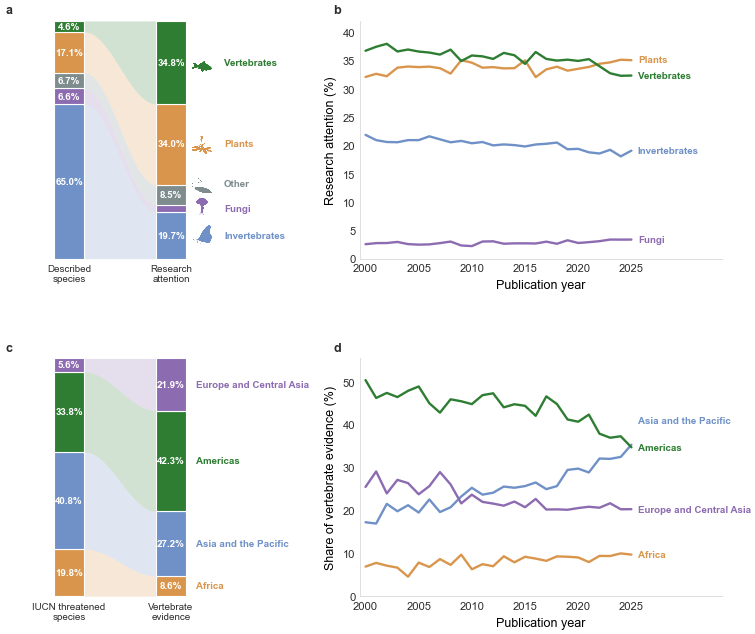

Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/04_taxonomic_lens/csv/04_anchor_resolution_by_year.csv
Anchor resolution 76.7% (2000) -> 66.9% (2025): later years rest on a smaller share of the corpus, which the Supplementary must state alongside the trend.


In [37]:
STACK_ORDER = tuple(CONFIG["benchmark_group_stack_order"])
RESIDUAL_GROUP = CONFIG["trend_residual_group"]

attention_trend = taxa_skew.taxonomic_attention_trend(
    anchor.included,
    benchmark_groups=BENCHMARK_GROUPS,
)
DESCRIBED_SHARES = ANCHOR["described_species_share_pct"].to_dict()
trend_summary = taxa_skew.summarise_attention_trend(
    attention_trend,
    described_shares=DESCRIBED_SHARES,
)
RESULTS.save_table(attention_trend, artifact("attention_trend_by_year"))
RESULTS.save_table(trend_summary, artifact("attention_trend_summary"))

display(
    trend_summary.set_index("broad_group")
    .reindex(BENCHMARK_GROUPS)
    .reset_index()[
        [
            "broad_group",
            "start_share_pct",
            "end_share_pct",
            "change_pp",
            "slope_pp_per_decade",
            "start_representation_ratio",
            "end_representation_ratio",
        ]
    ]
    .style.format(
        {
            "start_share_pct": "{:.2f}%",
            "end_share_pct": "{:.2f}%",
            "change_pp": "{:+.2f} pp",
            "slope_pp_per_decade": "{:+.2f}",
            "start_representation_ratio": "{:.2f}×",
            "end_representation_ratio": "{:.2f}×",
        }
    )
    .hide(axis="index")
)

# Volume growth is what makes the stability notable, so state it alongside.
YEARLY_TOTALS = (
    attention_trend.groupby("publication_year")["n_effective_publications_year"].first()
    if "n_effective_publications_year" in attention_trend
    else anchor.included.groupby("publication_year").size()
)
first_year, last_year = int(YEARLY_TOTALS.index.min()), int(YEARLY_TOTALS.index.max())
GROWTH_MULTIPLE = YEARLY_TOTALS.loc[last_year] / YEARLY_TOTALS.loc[first_year]
print(
    f"\nAnnual output {YEARLY_TOTALS.loc[first_year]:,.0f} ({first_year}) -> "
    f"{YEARLY_TOTALS.loc[last_year]:,.0f} ({last_year}): {GROWTH_MULTIPLE:.1f}x."
)
TREND = trend_summary.set_index("broad_group")
for group in ("Invertebrates", "Vertebrates"):
    row = TREND.loc[group]
    print(
        f"{group}: {row['start_share_pct']:.1f}% -> {row['end_share_pct']:.1f}% "
        f"({row['slope_pp_per_decade']:+.2f} pp/decade); representation "
        f"{row['start_representation_ratio']:.2f}x -> {row['end_representation_ratio']:.2f}x."
    )

# Combined 2x2: taxonomic mismatch/persistence on top, geographic mismatch/persistence
# below. Both rows call the same _stacked_pair/_trend_lines helpers, so the geographic
# row reads exactly like the taxonomic one -- that rhyme is the argument, since the two
# rows use unrelated benchmarks (GBIF described species, IUCN threatened species) and
# fail alike. `regional`/`regional_trend` are the *revised* (Starnes-benchmarked,
# article-deduplicated) tables from 2a-revised, not the legacy WDI ones from 2a.
# `region_left_caption` overrides the plotting module's birds+mammals-era default label
# -- the Starnes benchmark is all-taxa, not birds+mammals (see 2a-revised).
combined_figure = taxa_skew_plotting.plot_representation_and_trend(
    anchor_analysis.comparison,
    attention_trend,
    group_order=STACK_ORDER,
    group_colors=BROAD_COLORS,
    residual_group=RESIDUAL_GROUP,
    mapping=MAPPING,
    regional=revised_gap_regions,
    regional_trend=revised_gap_regional_trend,
    region_order=taxa_gap_plotting.REGION_ORDER,
    region_colors=taxa_gap_plotting.REGION_COLORS,
    region_left_caption="IUCN threatened\nspecies",
)
RESULTS.export_figure(
    combined_figure, artifact(CONFIG["combined_figure_filename"])
)
display(combined_figure)
plt.close(combined_figure)

# The caveat the Supplementary must disclose: composition is measured on a shrinking
# share of the corpus, because fewer recent publications resolve to a benchmark group.
ANCHOR_UTS = set(anchor.included["UT"])
resolution_by_year = (
    UNIVERSE.assign(resolved=UNIVERSE["UT"].isin(ANCHOR_UTS))
    .groupby("publication_year")
    .agg(n_universe=("UT", "nunique"), n_resolved=("resolved", "sum"))
    .assign(resolved_pct=lambda d: d["n_resolved"] / d["n_universe"] * 100.0)
    .reset_index()
)
RESULTS.save_table(resolution_by_year, artifact("anchor_resolution_by_year"))
RESOLUTION_START_PCT = float(resolution_by_year["resolved_pct"].iloc[0])
RESOLUTION_END_PCT = float(resolution_by_year["resolved_pct"].iloc[-1])
print(
    f"Anchor resolution {RESOLUTION_START_PCT:.1f}% ({first_year}) -> "
    f"{RESOLUTION_END_PCT:.1f}% ({last_year}): later years rest on a smaller share of "
    "the corpus, which the Supplementary must state alongside the trend."
)

## 3. Interpretation boundaries

What these numbers do and do not license.

In [38]:
BOUNDARIES = [
    "Counts are unique publications; a publication naming several groups is split "
    "across them, never counted once per group.",
    "Attention share measures what is published, not conservation need, ecological "
    "importance, population decline, or undescribed diversity.",
    "The described-diversity benchmark is GBIF accepted species-rank counts — a "
    "described-diversity proxy, not a species inventory. It is weakest for bacteria "
    "and archaea, where described counts trail actual diversity by orders of magnitude.",
    f"{RESOLUTION_START_PCT:.0f}% of in-scope publications resolved to a benchmarkable "
    f"group in {CONFIG['primary_start_year']} and {RESOLUTION_END_PCT:.0f}% in "
    f"{CONFIG['primary_end_year']}; later years rest on a smaller share of the corpus.",
    "The geographic comparison covers "
    f"{GEO_COVERAGE_PCT:.0f}% of the anchor scope -- the share carrying a mapped study "
    "country. Its benchmark (2a-revised; Starnes et al. 2026) is an all-taxa "
    "threatened-species count, not birds-and-mammals-only, because no taxon-specific "
    "breakdown exists in that release; the evidence side stays scoped to the broad "
    "Vertebrates group rather than being narrowed, so neither side claims a taxonomic "
    "match the other cannot back. The benchmark also sums Starnes' IPBES subregion "
    "counts to each region without a stated (or verifiable) additivity guarantee, so a "
    "species ranging across subregions of one region is likely counted more than once "
    "there -- see 2a-revised for detail. A legacy WDI-benchmarked, birds+mammals-only "
    "version (2a) is retained for comparison but no longer backs the reported figure.",
]
for boundary in BOUNDARIES:
    print(f"• {boundary}")

RESULTS.save_json(
    {
        "analysis": "taxonomic attention versus described diversity, and its trajectory",
        "manuscript_section": CONFIG["manuscript_section"],
        "prepared_schema_version": bundle.manifest["schema_version"],
        "prepared_grouping_rules_sha256": bundle.manifest["grouping_rules_sha256"],
        "direction": CONFIG["direction"],
        "primary_years": [CONFIG["primary_start_year"], CONFIG["primary_end_year"]],
        "universe_publications": N_UNIVERSE,
        "anchor_publications": N_ANCHOR,
        "vertebrate_share_pct": round(
            float(ANCHOR.at["Vertebrates", "fractional_attention_share_pct"]), 4
        ),
        "invertebrate_share_pct": round(
            float(ANCHOR.at["Invertebrates", "fractional_attention_share_pct"]), 4
        ),
        "annual_output_growth_multiple": round(float(GROWTH_MULTIPLE), 3),
        "resolution_start_pct": round(float(RESOLUTION_START_PCT), 4),
        "resolution_end_pct": round(float(RESOLUTION_END_PCT), 4),
        "geography_coverage_pct": round(float(GEO_COVERAGE_PCT), 4),
        "geographic_benchmark_source": "Starnes et al. (2026), Zenodo doi:10.5281/zenodo.18348560 "
        "-- superseded the World Bank WDI benchmark on 2026-08-16",
        "geographic_benchmark_scope": "all IUCN comprehensively-assessed taxa (CR+EN+VU), "
        "not birds+mammals-only; evidence stays scoped to the broad Vertebrates group",
        "bootstrap_replicates": CONFIG["bootstrap_replicates"],
        "random_seed": CONFIG["random_seed"],
        "interpretation_boundaries": BOUNDARIES,
        "reported_tables": [artifact(name) for name in (
            "denominators.csv",
            "attention_vs_described_diversity.csv",
            "attention_trend_by_year.csv",
            "attention_trend_summary.csv",
            "anchor_resolution_by_year.csv",
            "taxa_geography_coverage.csv",
        )] + [artifact(name) for name in (
            # Revised (2a-revised) -- backs the reported Figure 4c/d numbers.
            "starnes_threatened_species_by_region.csv",
            "vertebrate_evidence_by_region.csv",
            "evidence_vs_starnes_threatened_by_region.csv",
            "vertebrate_evidence_regional_trend_starnes.csv",
            "vertebrate_evidence_regional_trend_summary_starnes.csv",
            "starnes_threat_sensitivity_by_region.csv",
        )] + [artifact(name) for name in (
            # Legacy (2a) -- WDI-benchmarked, retained for comparison only.
            f"{GAP_SLUG}_evidence_vs_threatened_by_region.csv",
            f"{GAP_SLUG}_regional_evidence_trend.csv",
            f"{GAP_SLUG}_regional_evidence_trend_summary.csv",
            f"{GAP_SLUG}_evidence_by_country.csv",
            f"{GAP_SLUG}_evidence_vs_threatened.csv",
            "threatened_species_by_country.csv",
        )],

        "figures": [artifact(f"{CONFIG['combined_figure_filename']}.pdf")],
    },
    artifact("manifest"),
)
print("\nManifest written.")

• Counts are unique publications; a publication naming several groups is split across them, never counted once per group.
• Attention share measures what is published, not conservation need, ecological importance, population decline, or undescribed diversity.
• The described-diversity benchmark is GBIF accepted species-rank counts — a described-diversity proxy, not a species inventory. It is weakest for bacteria and archaea, where described counts trail actual diversity by orders of magnitude.
• 77% of in-scope publications resolved to a benchmarkable group in 2000 and 67% in 2025; later years rest on a smaller share of the corpus.
• The geographic comparison covers 56% of the anchor scope -- the share carrying a mapped study country. Its benchmark (2a-revised; Starnes et al. 2026) is an all-taxa threatened-species count, not birds-and-mammals-only, because no taxon-specific breakdown exists in that release; the evidence side stays scoped to the broad Vertebrates group rather than bein

## 4. The taxonomic hierarchy figure

`taxonomic_hierarchy.pdf` = Figure `taxonomic_hierarchy` in the main text — the sunburst
across Kingdom → Phylum → Class → Order, and the source of the Results paragraph's
Plantae/Chordata/Arthropoda/Mammalia/Insecta attention-vs-described-species figures.

### 4a. Pipeline contract and resolution audit

Reuses the accepted GBIF lineages from Section 1's resolution (exact and fuzzy-accepted
matches only). At each rank, duplicate paths within an article are collapsed and the
article rebalanced over its distinct complete paths — an Animalia-only item contributes at
kingdom only, an Arthropoda-only item at kingdom and phylum only, and so on. The GBIF side
streams the same fixed 28-Aug-2023 backbone as the Section 2 benchmark, restricted to
accepted species-rank rows, and separately reports how many rows have a complete path at
each rank.

**Alignment boundary**: research taxa were resolved through GBIF's current v2 API, while
the described-species benchmark is the fixed 28-Aug-2023 snapshot (confirmed in
`data/gbif/raw-2`, not a newer release). Kingdom containers for bacteria/archaea/viruses
bridge unambiguously; lower-rank renames are not guessed. Every comparison below keeps only
hierarchy paths common to both sources and reports what alignment costs before
renormalizing either side — which is also why the resolution and alignment audits below are
exported, not just the figure.

In [39]:
from data_helpers.analysis.taxa import hierarchy as taxa_hierarchy
from data_helpers.analysis.taxa import hierarchy_plotting as taxa_hierarchy_plotting

HIERARCHY_CONFIG = CONFIG["hierarchy_exploration"]
taxa_matches = pd.read_parquet(PREPARED.match_path)
hierarchy_evidence = taxa_hierarchy.build_rank_hierarchy_evidence(
    taxa_matches,
    PROJECT_ROOT / HIERARCHY_CONFIG["gbif_source"],
    publication_ids=anchor.included["UT"],
    benchmark_groups=BENCHMARK_GROUPS,
)

rank_resolution = hierarchy_evidence.resolution_audit
rank_alignment = hierarchy_evidence.alignment_audit
gbif_rank_source_audit = hierarchy_evidence.gbif_source_audit.assign(
    source=HIERARCHY_CONFIG["gbif_source"],
    raw_archive_metadata=HIERARCHY_CONFIG["gbif_raw_archive_metadata"],
)
RESULTS.save_table(rank_resolution, artifact("rank_hierarchy_resolution_audit"))
RESULTS.save_table(rank_alignment, artifact("rank_hierarchy_alignment_audit"))
RESULTS.save_table(gbif_rank_source_audit, artifact("rank_hierarchy_gbif_source_audit"))

display(
    rank_resolution.style.format(
        {
            "research_resolved_publications": "{:,}",
            "research_share_of_anchor_pct": "{:.2f}%",
            "research_newly_unresolved_from_previous_rank": "{:,}",
            "gbif_resolved_species": "{:,}",
            "gbif_share_of_accepted_species_pct": "{:.2f}%",
            "gbif_newly_unresolved_from_previous_rank": "{:,}",
        }
    ).hide(axis="index")
)
display(
    rank_alignment.style.format(
        {
            "research_attention_on_common_paths_pct": "{:.2f}%",
            "gbif_species_on_common_paths_pct": "{:.2f}%",
            "research_publications_with_common_path": "{:,}",
        }
    ).hide(axis="index")
)
class_resolution = rank_resolution.set_index("rank").loc["class"]
class_alignment = rank_alignment.set_index("rank").loc["class"]
print(
    f"Class is present for {class_resolution['research_resolved_publications']:,.0f} anchor "
    f"publications ({class_resolution['research_share_of_anchor_pct']:.1f}%). Exact class paths "
    f"shared with the fixed GBIF snapshot retain "
    f"{class_alignment['research_publications_with_common_path']:,.0f} publications and "
    f"{class_alignment['research_attention_on_common_paths_pct']:.1f}% of the pre-alignment "
    "class-resolved attention."
)


Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/04_taxonomic_lens/csv/04_rank_hierarchy_resolution_audit.csv
Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/04_taxonomic_lens/csv/04_rank_hierarchy_alignment_audit.csv
Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/04_taxonomic_lens/csv/04_rank_hierarchy_gbif_source_audit.csv


rank,research_resolved_publications,research_share_of_anchor_pct,research_newly_unresolved_from_previous_rank,gbif_resolved_species,gbif_share_of_accepted_species_pct,gbif_newly_unresolved_from_previous_rank
kingdom,"171,791",100.00%,0,"2,614,593",100.00%,0
phylum,"161,668",94.11%,"10,123","2,601,849",99.51%,"12,744"
class,"158,500",92.26%,"3,168","2,498,498",95.56%,"103,351"
order,"149,709",87.15%,"8,791","2,418,924",92.52%,"79,574"


rank,n_research_paths,n_gbif_paths,n_exact_common_paths,research_attention_on_common_paths_pct,gbif_species_on_common_paths_pct,research_publications_with_common_path
kingdom,8,9,8,100.00%,99.96%,"171,791"
phylum,110,271,95,93.69%,98.50%,"154,348"
class,310,706,223,75.95%,96.92%,"124,816"
order,1026,2548,723,72.45%,90.91%,"113,342"


Class is present for 158,500 anchor publications (92.3%). Exact class paths shared with the fixed GBIF snapshot retain 124,816 publications and 75.9% of the pre-alignment class-resolved attention.


### 4b. Sunburst figure

Four rings (Kingdom → Phylum → Class → Order); angular span encodes research attention
only. The compact hierarchy under the wheel pairs each named group's (research attention,
described species) through Class — research attention on the Order-aligned 113,342-article
subset, described species on the full benchmarkable GBIF base (2,590,832 species, the same
denominator Section 2 uses). The two denominators are independent by design; complete Order
detail lives in the exported table, not the figure.

Named-node selection: a Class expands to Order when at most 6 named Orders leave no more
than 5% residual (large Classes reaching 5% of global attention may use a relaxed
threshold); Orders reaching 1% on either aligned measure stay named. Everything below
threshold folds into a parent-coloured `Remaining` row; only the combined `Other kingdoms`
branch stays neutral grey.

Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/04_taxonomic_lens/csv/04_rank_hierarchy_order_comparison.csv
Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/04_taxonomic_lens/csv/04_rank_hierarchy_full_gbif_counts.csv
Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/04_taxonomic_lens/csv/04_rank_hierarchy_gbif_display_assignments.csv
Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/04_taxonomic_lens/csv/04_rank_hierarchy_sunburst_nodes.csv
Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/04_taxonomic_lens/csv/04_rank_hierarchy_sunburst_audit.csv


metric,value
Comparison research publications,113342.000000
Aligned GBIF species used for display selection,2199000.000000
Exact shared source Order paths,723.000000
Plotted hierarchy nodes,93.000000
Terminal plotted nodes,71.000000
Named Classes expanded to Order,11.000000
Large Classes using relaxed Order expansion,4.000000
Named Classes stopped at Class,18.000000
Named Kingdoms stopped at Kingdom,1.000000
Order maximum named children,6.000000


✓ Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/04_taxonomic_lens/figures/04_taxonomic_hierarchy.pdf


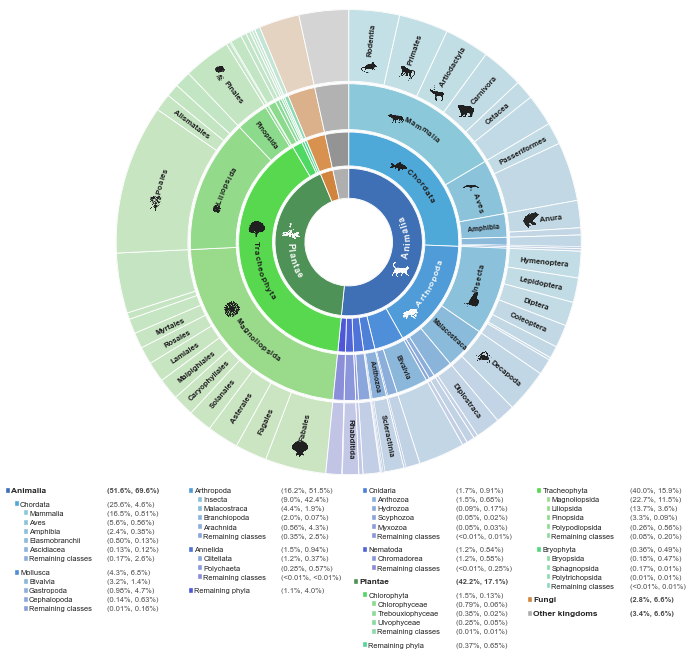

Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/04_taxonomic_lens/csv/04_rank_hierarchy_sunburst_manifest.json


PosixPath('/Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/04_taxonomic_lens/csv/04_rank_hierarchy_sunburst_manifest.json')

In [40]:
SUNBURST_CONFIG = HIERARCHY_CONFIG["sunburst"]
order_comparison = taxa_hierarchy.compare_exact_rank_paths(
    hierarchy_evidence.research_attributions,
    hierarchy_evidence.gbif_counts,
    rank=SUNBURST_CONFIG["terminal_rank"],
)
sunburst_selection = taxa_hierarchy.build_research_attention_sunburst(
    order_comparison,
    major_kingdoms=SUNBURST_CONFIG["major_kingdoms"],
    terminal_kingdoms=SUNBURST_CONFIG["terminal_kingdoms"],
    phylum_min_within_parent_pct=SUNBURST_CONFIG["phylum_min_within_parent_pct"],
    class_min_within_parent_pct=SUNBURST_CONFIG["class_min_within_parent_pct"],
    order_max_children=SUNBURST_CONFIG["order_max_children"],
    order_max_other_within_parent_pct=SUNBURST_CONFIG["order_max_other_within_parent_pct"],
    relaxed_order_expansion_min_class_research_share_pct=SUNBURST_CONFIG["relaxed_order_expansion_min_class_research_share_pct"],
    order_named_min_global_share_pct=SUNBURST_CONFIG["order_named_min_global_share_pct"],
)
sunburst = taxa_hierarchy.apply_independent_gbif_benchmark(
    sunburst_selection,
    hierarchy_evidence.gbif_counts,
    bundle.benchmark.counts,
    root_group_mapping=SUNBURST_CONFIG["gbif_root_group_mapping"],
    phylum_min_within_parent_pct=SUNBURST_CONFIG["phylum_min_within_parent_pct"],
    class_min_within_parent_pct=SUNBURST_CONFIG["class_min_within_parent_pct"],
    order_named_min_global_share_pct=SUNBURST_CONFIG["order_named_min_global_share_pct"],
)
sunburst_nodes = sunburst.nodes.copy()
sunburst_nodes["plot_color"] = sunburst_nodes["node_id"].map(
    taxa_hierarchy_plotting.sunburst_node_colors(
        sunburst_nodes,
        rank_lightness=SUNBURST_CONFIG["rank_color_lightness"],
        rank_saturation=SUNBURST_CONFIG["rank_color_saturation"],
    )
)

# The public export carries the exact paths, paired measures, within-parent
# percentages, terminal flags, pruning reason, and colour used in the figure.
RESULTS.save_table(order_comparison, artifact("rank_hierarchy_order_comparison"))
RESULTS.save_table(hierarchy_evidence.gbif_counts, artifact("rank_hierarchy_full_gbif_counts"))
RESULTS.save_table(sunburst.assignments, artifact("rank_hierarchy_gbif_display_assignments"))
RESULTS.save_table(sunburst_nodes, artifact("rank_hierarchy_sunburst_nodes"))
RESULTS.save_table(sunburst.audit, artifact("rank_hierarchy_sunburst_audit"))
display(sunburst.audit.style.hide(axis="index"))

sunburst_figure = taxa_hierarchy_plotting.plot_research_attention_sunburst(
    sunburst_nodes,
    rank_lightness=SUNBURST_CONFIG["rank_color_lightness"],
    rank_saturation=SUNBURST_CONFIG["rank_color_saturation"],
    legend_order_min_global_share_pct=SUNBURST_CONFIG["legend_order_min_global_share_pct"],
    legend_show_orders=SUNBURST_CONFIG["legend_show_orders"],
    mapping=MAPPING,
    in_wheel_label_min_angle_deg=SUNBURST_CONFIG["in_wheel_label_min_angle_deg"],
    ring_widths=SUNBURST_CONFIG["rank_ring_widths"],
    class_label_min_angle_deg=SUNBURST_CONFIG["class_label_min_angle_deg"],
    order_label_min_angle_deg=SUNBURST_CONFIG["order_label_min_angle_deg"],
    extend_terminal_branches=SUNBURST_CONFIG["extend_terminal_branches"],
    inner_radius=SUNBURST_CONFIG["inner_radius"],
)
sunburst_labelled_taxa = list(sunburst_figure._sunburst_labelled_taxa)
sunburst_class_labelled_taxa = list(sunburst_figure._sunburst_class_labelled_taxa)
sunburst_order_labelled_taxa = list(sunburst_figure._sunburst_order_labelled_taxa)
sunburst_order_icon_taxa = list(sunburst_figure._sunburst_order_icon_taxa)
sunburst_terminal_continuations = list(sunburst_figure._sunburst_terminal_continuations)
RESULTS.export_figure(
    sunburst_figure, artifact(SUNBURST_CONFIG["figure_filename"])
)
display(sunburst_figure)
plt.close(sunburst_figure)

RESULTS.save_json(
    {
        "analysis": "research-attention taxonomic sunburst (Figure taxonomic_hierarchy)",
        "status": "manuscript figure -- backs Figure taxonomic_hierarchy and the kingdom/phylum/class stats in the first Results paragraph",
        "rank_path": list(taxa_hierarchy.RANKS),
        "comparison_contract": "exact Order-aligned research geometry with an independent complete benchmarkable accepted-GBIF denominator",
        "angular_encoding": "article-balanced research attention",
        "described_species_encoding": "paired percentage through Class in the compact hierarchy, using the complete benchmarkable accepted-GBIF base; complete Order values remain in the exported table",
        "legend_terminal_rank": "order" if SUNBURST_CONFIG["legend_show_orders"] else "class",
        "remainder_contract": "display-only local complement: full parent GBIF count minus individually displayed full-GBIF child counts; actual assignments are exported",
        "order_remainder_encoding": "parent-coloured without hatching; combines every non-displayed Order and species lacking Order under the expanded Class",
        "in_wheel_labelled_taxa": sunburst_labelled_taxa,
        "in_wheel_class_labelled_taxa": sunburst_class_labelled_taxa,
        "in_wheel_order_labelled_taxa": sunburst_order_labelled_taxa,
        "in_wheel_order_icon_taxa": sunburst_order_icon_taxa,
        "terminal_continuations": sunburst_terminal_continuations,
        "in_wheel_clipart_mapping": {
            taxon: MAPPING["sunburst_clipart"][taxon]
            for taxon in sunburst_labelled_taxa
        },
        "in_wheel_order_clipart_mapping": {
            taxon: MAPPING["sunburst_order_clipart"][taxon]
            for taxon in sunburst_order_icon_taxa
        },
        "comparison_publications": int(order_comparison["comparison_research_publications"].iloc[0]),
        "comparison_gbif_species": int(sunburst_nodes["comparison_gbif_species"].iloc[0]),
        "aligned_gbif_species_used_for_display_selection": int(order_comparison["comparison_gbif_species"].iloc[0]),
        "n_exact_common_order_paths": len(order_comparison),
        "selection": SUNBURST_CONFIG,
        "tables": [
            artifact("rank_hierarchy_order_comparison.csv"),
            artifact("rank_hierarchy_full_gbif_counts.csv"),
            artifact("rank_hierarchy_gbif_display_assignments.csv"),
            artifact("rank_hierarchy_sunburst_nodes.csv"),
            artifact("rank_hierarchy_sunburst_audit.csv"),
        ],
        "figures": [
            artifact(f"{SUNBURST_CONFIG['figure_filename']}.pdf"),
        ],
    },
    artifact("rank_hierarchy_sunburst_manifest"),
)
